In [22]:
!pip install "paddleocr>=2.0.1"


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
!python --version

Python 3.13.5


In [24]:
!pip list | findstr paddle

paddleocr               3.5.0
paddlepaddle            3.3.1
paddlex                 3.5.1


In [25]:
!nvidia-smi

Mon May 11 12:22:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.83                 Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   43C    P8              1W /   80W |     392MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from difflib import SequenceMatcher
from tqdm import tqdm
from paddleocr import PaddleOCR
from cer import calculate_cer

plt.rcParams['font.family'] = 'Tahoma'

In [27]:
thai_map = {
    "A01": "ก", "A02": "ข", "A03": "ฃ", "A04": "ค", "A05": "ฅ",
    "A06": "ฆ", "A07": "ง", "A08": "จ", "A09": "ฉ", "A10": "ช",
    "A11": "ซ", "A12": "ฌ", "A13": "ญ", "A14": "ฎ", "A15": "ฏ",
    "A16": "ฐ", "A17": "ฑ", "A18": "ฒ", "A19": "ณ", "A20": "ด",
    "A21": "ต", "A22": "ถ", "A23": "ท", "A24": "ธ", "A25": "น",
    "A26": "บ", "A27": "ป", "A28": "ผ", "A29": "ฝ", "A30": "พ",
    "A31": "ฟ", "A32": "ภ", "A33": "ม", "A34": "ย", "A35": "ร",
    "A36": "ล", "A37": "ว", "A38": "ศ", "A39": "ษ", "A40": "ส",
    "A41": "ห", "A42": "ฬ", "A43": "อ", "A44": "ฮ",
}

In [28]:
def normalize_text(text):
    """Keep only Thai chars and digits."""
    return re.sub(r'[^\u0e00-\u0e7f0-9]', '', text)

def decode_thai_char(label):
    return thai_map.get(label, label)

def load_province_map(csv_path="province_map.csv"):
    df = pd.read_csv(csv_path)
    return dict(zip(df['abbr_en'], df['province_th']))

def decode_label(label, province_map):
    if label.isnumeric():
        return label
    if label.startswith("A"):
        return decode_thai_char(label)
    return province_map.get(label, label)

In [29]:
ocr = PaddleOCR(
    use_doc_orientation_classify=False, 
    use_doc_unwarping=False, 
    use_textline_orientation=False,
    lang="th"
)
# text detection + text recognition

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\sschw\.paddlex\official_models\PP-OCRv5_server_det`.


RuntimeError: Engine 'paddle_static' is unavailable because dependency 'paddlepaddle' is not installed.

In [ ]:
def parse_paddle_result(result):
    res = result[0]  # first image

    texts = res["rec_texts"]
    scores = res["rec_scores"]
    polys = res["rec_polys"]  # use rec_polys (aligned with text)

    output = []
    for text, score, poly in zip(texts, scores, polys):
        output.append({
            "text": text,
            "score": float(score),
            "bbox": poly.tolist()
        })

    return output

def plot_ocr(image_path, result):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    parsed = parse_paddle_result(result)

    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)

    for item in parsed:
        bbox = item["bbox"]
        text = item["text"]
        prob = item["score"]

        xs = [p[0] for p in bbox] + [bbox[0][0]]
        ys = [p[1] for p in bbox] + [bbox[0][1]]

        plt.plot(xs, ys, linewidth=2)

        x, y = bbox[0]
        plt.text(
            x, y - 10,
            f"{text} ({prob:.2f})",
            fontsize=12,
            bbox=dict(facecolor='white', alpha=0.7)
        )

    plt.axis('off')
    plt.title('PaddleOCR Bounding Boxes')
    plt.show()

In [ ]:
result = ocr.predict("truck_plate.jpg")
plot_ocr("truck_plate.jpg", result)

NameError: name 'ocr' is not defined

In [ ]:
from difflib import get_close_matches

THAI_PROVINCES = [
    "กรุงเทพมหานคร", "กระบี่", "กาญจนบุรี", "กาฬสินธุ์", "กำแพงเพชร",
    "ขอนแก่น", "จันทบุรี", "ฉะเชิงเทรา", "ชลบุรี", "ชัยนาท",
    "ชัยภูมิ", "ชุมพร", "เชียงราย", "เชียงใหม่", "ตรัง",
    "ตราด", "ตาก", "นครนายก", "นครปฐม", "นครพนม",
    "นครราชสีมา", "นครศรีธรรมราช", "นครสวรรค์", "นนทบุรี", "นราธิวาส",
    "น่าน", "บึงกาฬ", "บุรีรัมย์", "ปทุมธานี", "ประจวบคีรีขันธ์",
    "ปราจีนบุรี", "ปัตตานี", "พระนครศรีอยุธยา", "พะเยา", "พังงา",
    "พัทลุง", "พิจิตร", "พิษณุโลก", "เพชรบุรี", "เพชรบูรณ์",
    "แพร่", "ภูเก็ต", "มหาสารคาม", "มุกดาหาร", "แม่ฮ่องสอน",
    "ยโสธร", "ยะลา", "ร้อยเอ็ด", "ระนอง", "ระยอง",
    "ราชบุรี", "ลพบุรี", "ลำปาง", "ลำพูน", "เลย",
    "ศรีสะเกษ", "สกลนคร", "สงขลา", "สตูล", "สมุทรปราการ",
    "สมุทรสงคราม", "สมุทรสาคร", "สระแก้ว", "สระบุรี", "สิงห์บุรี",
    "สุโขทัย", "สุพรรณบุรี", "สุราษฎร์ธานี", "สุรินทร์", "หนองคาย",
    "หนองบัวลำภู", "อ่างทอง", "อำนาจเจริญ", "อุดรธานี", "อุตรดิตถ์",
    "อุทัยธานี", "อุบลราชธานี",
]

# Expected top-line format: optional leading digit(s), 2 Thai chars, digits
# e.g. "กม8300", "9กณ428", "3กจ528", "ขข716", "737378"
TOP_PATTERN = re.compile(
    r'^(\d{0,2})([ก-ฮ]{0,2})(\d{1,6})$'
)

def clean_top(text):
    """
    Enforce Thai license plate top-line structure.
    Valid formats:
      - Pure digits (old-style): 5-7 digits  e.g. 737378
      - Thai prefix: 0-1 digit + 2 Thai chars + 2-4 digits  e.g. กม8300, 9กณ428
    Strategy: extract all Thai chars and digits in order, then trim to expected length.
    """
    # Separate into thai chars and digits preserving order
    thai_chars = re.findall(r'[ก-ฮ]', text)
    digits     = re.findall(r'\d', text)
    
    # Detect format from ground-truth structure
    # Case 1: pure digit plate (no Thai chars expected)
    if len(thai_chars) == 0:
        # Keep only up to 7 digits (Thai plates max)
        return ''.join(digits[:7])
    
    # Case 2: has Thai chars — reconstruct prefix + number
    # Find position of first Thai char in original to detect leading digit
    first_thai_pos = next((i for i, c in enumerate(text) if '\u0e00' <= c <= '\u0e7f'), len(text))
    leading_digits = re.findall(r'\d', text[:first_thai_pos])
    
    # Take max 1 leading digit, exactly 2 Thai chars, max 4 trailing digits
    lead  = ''.join(leading_digits[:1])
    thai  = ''.join(thai_chars[:2])
    # trailing digits: everything after the last Thai char
    last_thai_pos = max(i for i, c in enumerate(text) if '\u0e00' <= c <= '\u0e7f')
    trail_digits  = re.findall(r'\d', text[last_thai_pos+1:])
    trail = ''.join(trail_digits[:4])
    
    return lead + thai + trail


def snap_province(text, cutoff=0.6):
    """
    Fuzzy-snap to nearest valid province.
    Uses higher cutoff (0.6) to avoid wrong snaps like ชลบุรี→ลพบุรี.
    Falls back to the raw text if no match found.
    """
    if text in THAI_PROVINCES:
        return text
    
    # Try character-level similarity with higher cutoff first
    matches = get_close_matches(text, THAI_PROVINCES, n=1, cutoff=cutoff)
    if matches:
        return matches[0]
    
    # If no match, try prefix matching — province names rarely share first 3 chars
    prefix = text[:3] if len(text) >= 3 else text
    prefix_matches = [p for p in THAI_PROVINCES if p.startswith(prefix)]
    if len(prefix_matches) == 1:
        return prefix_matches[0]
    
    return text   # give up, return as-is


def clean_bottom(text):
    """Strip non-Thai chars then snap to nearest province."""
    thai_only = re.sub(r'[^\u0e00-\u0e7f]', '', text)
    if not thai_only:
        return text
    return snap_province(thai_only)

In [ ]:
def make_paddle_reader(lang="th"):
    return PaddleOCR(
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
        lang=lang,
    )

def parse_paddle_result(result):
    """Convert PaddleOCR output → list of {text, score, bbox:[x1,y1,x2,y2]}."""
    res = result[0]  # first (and only) image
    output = []
    for text, score, poly in zip(res["rec_texts"], res["rec_scores"], res["rec_polys"]):
        pts = np.array(poly)
        x1, y1 = int(pts[:, 0].min()), int(pts[:, 1].min())
        x2, y2 = int(pts[:, 0].max()), int(pts[:, 1].max())
        output.append({
            "text":  text,
            "score": float(score),
            "bbox":  [x1, y1, x2, y2],
        })
    return output

def build_ground_truth(csv_path, image_dir, province_map_path="province_map.csv",
                       plate_margin_frac=0.05, filename=None):
    df = pd.read_csv(csv_path)
    province_map = load_province_map(province_map_path)

    # ← accept filename directly instead of idx
    df_img = df[df['filename'] == filename].copy()
    if df_img.empty:
        raise ValueError(f"Filename not found in CSV: {filename}")

    img = cv2.imread(os.path.join(image_dir, filename))
    img_h, img_w = img.shape[:2]

    boxes = []
    for _, row in df_img.iterrows():
        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        label = decode_label(str(row['class']), province_map)

        if (xmax - xmin) < plate_margin_frac * img_w:
            continue
        if (ymax - ymin) < plate_margin_frac * img_h:
            continue
        if (xmin + xmax) / 2 < 0.08 * img_w:
            continue

        boxes.append({
            "bbox": [xmin, ymin, xmax, ymax],
            "label": label,
            "y_center": (ymin + ymax) / 2,
        })

    y_vals = np.array([b["y_center"] for b in boxes], dtype=np.float32).reshape(-1, 1)
    _, km_labels, centers = cv2.kmeans(
        y_vals, 2, None,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2),
        10, cv2.KMEANS_RANDOM_CENTERS,
    )
    top_cluster = int(np.argmin(centers))
    km_labels = km_labels.flatten()

    def merge(line):
        xs = [b["bbox"][0] for b in line] + [b["bbox"][2] for b in line]
        ys = [b["bbox"][1] for b in line] + [b["bbox"][3] for b in line]
        return {"text": "".join(b["label"] for b in line),
                "bbox": [min(xs), min(ys), max(xs), max(ys)]}

    top_line    = sorted([b for b, l in zip(boxes, km_labels) if l == top_cluster],
                         key=lambda x: x["bbox"][0])
    bottom_line = sorted([b for b, l in zip(boxes, km_labels) if l != top_cluster],
                         key=lambda x: x["bbox"][0])

    return {
        "filename": filename,
        "image_w": img_w, "image_h": img_h,
        "top":    merge(top_line),
        "bottom": merge(bottom_line),
    }

def iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    return inter / ((ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter)

def run_paddleocr(image_path, gt, conf_threshold=0.5, reader=None):
    if reader is None:
        reader = make_paddle_reader()

    raw        = reader.predict(image_path)
    detections = parse_paddle_result(raw)

    gt_top_y_center    = (gt["top"]["bbox"][1]    + gt["top"]["bbox"][3])    / 2
    gt_bottom_y_center = (gt["bottom"]["bbox"][1] + gt["bottom"]["bbox"][3]) / 2

    result = {"top": [], "bottom": [], "other": []}

    for det in detections:
        if det["score"] < conf_threshold:
            continue
        text = normalize_text(det["text"])
        if not text:
            continue

        bbox         = det["bbox"]
        det_y_center = (bbox[1] + bbox[3]) / 2
        iou_top      = iou(bbox, gt["top"]["bbox"])
        iou_bottom   = iou(bbox, gt["bottom"]["bbox"])

        entry = {"text": text, "bbox": bbox, "conf": round(det["score"], 3)}

        if iou_top == 0 and iou_bottom == 0:
            dist_top    = abs(det_y_center - gt_top_y_center)
            dist_bottom = abs(det_y_center - gt_bottom_y_center)
            if dist_top <= dist_bottom:
                result["top"].append(entry)
            else:
                result["bottom"].append(entry)
        elif iou_top >= iou_bottom:
            result["top"].append(entry)
        else:
            result["bottom"].append(entry)

    for key in ("top", "bottom"):
        result[key].sort(key=lambda x: x["bbox"][0])

    # ── Post-process ─────────────────────────────────────────────
    top_raw    = "".join(r["text"] for r in result["top"])
    bottom_raw = "".join(r["text"] for r in result["bottom"])

    if result["top"]:
        result["top"] = [{
            **result["top"][0],
            "text": clean_top(top_raw),
        }]
    if result["bottom"]:
        result["bottom"] = [{
            **result["bottom"][0],
            "text": clean_bottom(bottom_raw),
        }]

    return result

def evaluate(gt, ocr_result):
    metrics = {}
    for line in ("top", "bottom"):
        gt_text   = gt[line]["text"]
        pred_text = "".join(r["text"] for r in ocr_result[line])
        mean_conf = (np.mean([r["conf"] for r in ocr_result[line]])
                     if ocr_result[line] else 0.0)
        line_cer  = calculate_cer([gt_text], [pred_text])
        metrics[line] = {
            "gt_text":     gt_text,
            "pred_text":   pred_text,
            "cer":         round(line_cer, 4),
            "car":         round(max(0.0, 1 - line_cer), 4),
            "exact_match": gt_text == pred_text,
            "mean_conf":   round(mean_conf, 3),
            "n_boxes":     len(ocr_result[line]),
        }
    metrics["overall"] = {
        "exact_match_both": all(metrics[l]["exact_match"] for l in ("top", "bottom")),
        "mean_cer": round(np.mean([metrics[l]["cer"] for l in ("top", "bottom")]), 4),
        "mean_car": round(np.mean([metrics[l]["car"] for l in ("top", "bottom")]), 4),
    }
    return metrics

def evaluate_all(csv_path, image_dir, province_map_path="province_map.csv",
                 conf_threshold=0.5, output_csv="paddle_eval_results.csv", reader=None):
    df_all = pd.read_csv(csv_path)
    filenames = df_all['filename'].unique()   # ← deduplicated list of images

    if reader is None:
        reader = make_paddle_reader()

    records = []
    errors  = []

    for filename in tqdm(filenames, desc="Evaluating PaddleOCR"):
        try:
            gt = build_ground_truth(          # ← pass filename, not idx
                csv_path, image_dir, province_map_path, filename=filename
            )
            img_path   = os.path.join(image_dir, filename)
            ocr_result = run_paddleocr(img_path, gt,
                                       conf_threshold=conf_threshold,
                                       reader=reader)
            metrics = evaluate(gt, ocr_result)

            records.append({
                "filename":         filename,
                "top_gt":           metrics["top"]["gt_text"],
                "top_pred":         metrics["top"]["pred_text"],
                "top_cer":          metrics["top"]["cer"],
                "top_car":          metrics["top"]["car"],
                "top_exact":        metrics["top"]["exact_match"],
                "top_conf":         metrics["top"]["mean_conf"],
                "bottom_gt":        metrics["bottom"]["gt_text"],
                "bottom_pred":      metrics["bottom"]["pred_text"],
                "bottom_cer":       metrics["bottom"]["cer"],
                "bottom_car":       metrics["bottom"]["car"],
                "bottom_exact":     metrics["bottom"]["exact_match"],
                "bottom_conf":      metrics["bottom"]["mean_conf"],
                "mean_cer":         metrics["overall"]["mean_cer"],
                "mean_car":         metrics["overall"]["mean_car"],
                "exact_match_both": metrics["overall"]["exact_match_both"],
            })

        except Exception as e:
            errors.append({"filename": filename, "error": str(e)})

    if errors:
        print(f"\n⚠️  {len(errors)} images failed. First 5 errors:")
        for err in errors[:5]:
            print(f"  {err['filename']}: {err['error']}")
        pd.DataFrame(errors).to_csv(
            output_csv.replace(".csv", "_errors.csv"), index=False, encoding="utf-8-sig"
        )

    results_df = pd.DataFrame(records)
    results_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

    ok = results_df.dropna(subset=["top_cer"])
    print(f"\n{'='*45}")
    print(f"  Total images    : {len(filenames)}")
    print(f"  Successful      : {len(ok)}")
    print(f"  Failed / skipped: {len(errors)}")
    print(f"{'='*45}")
    if len(ok):
        print(f"  Top    CER : {ok['top_cer'].mean():.4f}")
        print(f"  Bottom CER : {ok['bottom_cer'].mean():.4f}")
        print(f"  Mean   CER : {ok['mean_cer'].mean():.4f}")
        print(f"{'─'*45}")
        print(f"  Top    CAR : {ok['top_car'].mean():.4f}")
        print(f"  Bottom CAR : {ok['bottom_car'].mean():.4f}")
        print(f"  Mean   CAR : {ok['mean_car'].mean():.4f}")
    print(f"{'='*45}")
    print(f"  Saved → {output_csv}")

    return results_df

In [ ]:
results_df = evaluate_all(
    csv_path=r'LPR-plate-1\test\_annotations.csv',
    image_dir=r'LPR-plate-1\test',
    province_map_path='province_map.csv',
    output_csv='paddle_eval_results.csv',
)

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Auto\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('th_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Auto\.paddlex\official_models\th_PP-OCRv5_mobile_rec`.
Evaluating PaddleOCR: 100%|██████████| 200/200 [00:47<00:00,  4.24it/s]


  Total images    : 200
  Successful      : 200
  Failed / skipped: 0
  Top    CER : 0.2040
  Bottom CER : 0.2952
  Mean   CER : 0.2496
─────────────────────────────────────────────
  Top    CAR : 0.7960
  Bottom CAR : 0.7048
  Mean   CAR : 0.7504
  Saved → paddle_eval_results.csv


In [ ]:
def evaluate_plate(csv_path, image_dir, province_map_path="province_map.csv",
                   filename=None, idx=0, conf_threshold=0.5, reader=None):
    # resolve filename from idx if not given directly
    if filename is None:
        df = pd.read_csv(csv_path)
        filename = df['filename'].unique()[idx]

    gt = build_ground_truth(csv_path, image_dir, province_map_path, filename=filename)
    img_path = os.path.join(image_dir, gt["filename"])

    if reader is None:
        reader = make_paddle_reader()

    print(f"[GT]  top='{gt['top']['text']}'  bottom='{gt['bottom']['text']}'")
    ocr_result = run_paddleocr(img_path, gt, conf_threshold=conf_threshold, reader=reader)

    for line in ("top", "bottom", "other"):
        print(f"[OCR] {line}: {[(r['text'], r['conf']) for r in ocr_result[line]]}")

    metrics = evaluate(gt, ocr_result)
    for line in ("top", "bottom"):
        m = metrics[line]
        print(f"  {line}: gt='{m['gt_text']}' pred='{m['pred_text']}' "
              f"CER={m['cer']:.2%}  CAR={m['car']:.2%}  exact={m['exact_match']}")
    print(f"  overall: {metrics['overall']}")

    # ── plot ──
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Ground Truth  vs  PaddleOCR", fontsize=15, fontweight='bold')

    def draw_box(ax, bbox, text, color, linestyle='-'):
        xmin, ymin, xmax, ymax = bbox
        ax.add_patch(patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none', linestyle=linestyle,
        ))
        ax.text(xmin, ymin - 8, text, fontsize=11, color=color,
                bbox=dict(facecolor='white', alpha=0.75, pad=2, edgecolor='none'))

    for ax, title, draw_fn in [
        (axes[0], "Ground Truth", lambda ax: [
            draw_box(ax, gt["top"]["bbox"],    f'TOP: {gt["top"]["text"]}',    'lime'),
            draw_box(ax, gt["bottom"]["bbox"], f'BOT: {gt["bottom"]["text"]}', 'deepskyblue'),
        ]),
        (axes[1], "PaddleOCR", lambda ax: [
            [draw_box(ax, r["bbox"], f'{r["text"]} ({r["conf"]})', col,
                      '--' if line == 'other' else '-')
             for r in ocr_result[line]]
            for line, col in [("top", "orange"), ("bottom", "deepskyblue"), ("other", "red")]
        ]),
    ]:
        ax.imshow(image)
        ax.set_title(title, fontsize=12)
        draw_fn(ax)
        ax.axis('off')

    summary = (
        f'[TOP] gt="{metrics["top"]["gt_text"]}" pred="{metrics["top"]["pred_text"]}"'
        f'  CER={metrics["top"]["cer"]:.2%}  CAR={metrics["top"]["car"]:.2%}\n'
        f'[BOT] gt="{metrics["bottom"]["gt_text"]}" pred="{metrics["bottom"]["pred_text"]}"'
        f'  CER={metrics["bottom"]["cer"]:.2%}  CAR={metrics["bottom"]["car"]:.2%}\n'
        f'mean CER={metrics["overall"]["mean_cer"]:.2%}'
        f'  mean CAR={metrics["overall"]["mean_car"]:.2%}'
        f'  exact={metrics["overall"]["exact_match_both"]}'
    )
    axes[1].set_title(summary, fontsize=9, loc='left')
    plt.tight_layout()
    plt.show()

    return gt, ocr_result, metrics

[GT]  top='ผร5381'  bottom='ชลบุรี'
[OCR] top: [('ผ5381', 0.617)]
[OCR] bottom: []
[OCR] other: []
  top: gt='ผร5381' pred='ผ5381' CER=16.67%  CAR=83.33%  exact=False
  bottom: gt='ชลบุรี' pred='' CER=100.00%  CAR=0.00%  exact=False
  overall: {'exact_match_both': False, 'mean_cer': np.float64(0.5834), 'mean_car': np.float64(0.4166)}


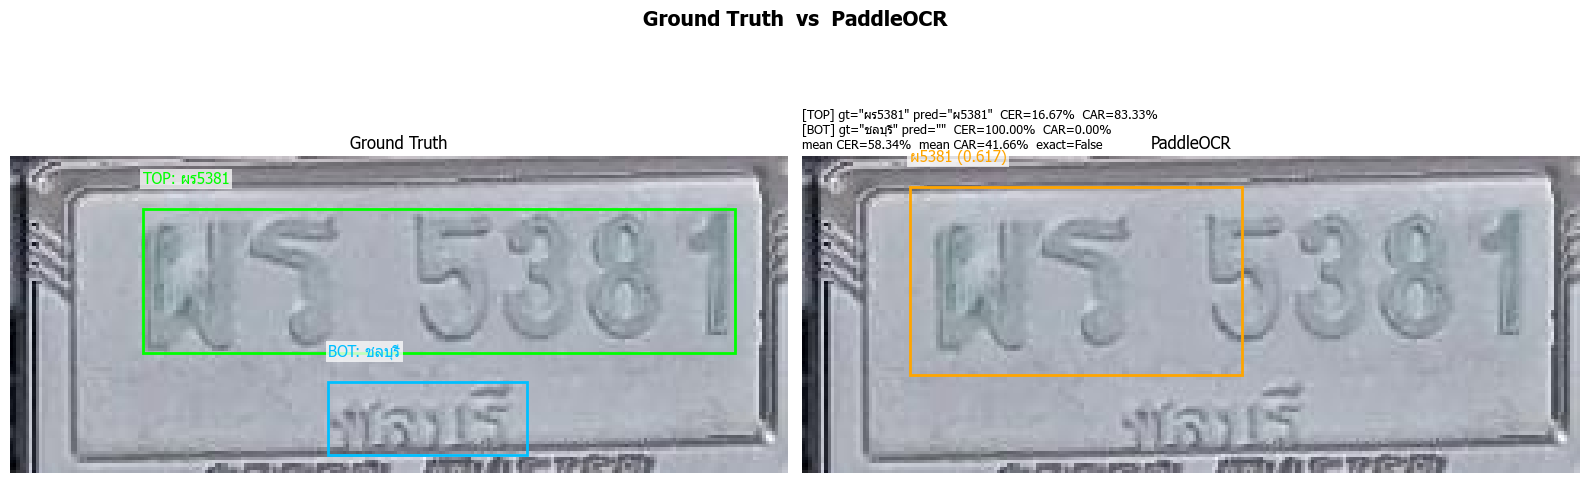

In [ ]:
_ = evaluate_plate(
    csv_path=r'LPR-plate-1\test\_annotations.csv',
    image_dir=r'LPR-plate-1\test',
    province_map_path='province_map.csv',
    idx=2,
    reader=ocr,
)

In [ ]:
results_df[["bottom_gt", "bottom_pred"]].values.tolist()

[['ชลบุรี', 'ซัลบริ'],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['ชลบุรี', ''],
 ['นนทบุรี', 'นนทบุรี'],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['สมุทรปราการ', 'สมุทรปราการ'],
 ['ระยอง', 'ร'],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['นครสวรรค์', 'มครบรร'],
 ['ชลบุรี', 'ชลบุรี'],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['ชบ58', 'ชบ'],
 ['ชลบุรี', ''],
 ['สมุทรปราการ', 'สมุทรปราการ'],
 ['สมุทรปราการ', 'สมุทรปราการ'],
 ['สมุทรสงคราม', 'สมุทรสงคราม'],
 ['กรุงเทพมหานคร', ''],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['สมุทรสาคร', 'สมุทรสาคร'],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['กรุงเทพมหานคร', ''],
 ['กรุงเทพมหานคร', 'กรุงเทพมหานคร'],
 ['ชลบุรี', ''],
 ['กรุงเทพมหานคร', 'รงท'],
 ['สมุทรปราการ', 'สมุทรปราการ'],
 ['ชลบุรี', 'ชลบุรี'],
 ['กรุงเทพมหานคร', ''],
 ['สระบุรี', 'สระบุรี'],
 ['ชลบุรี', 'ชลบุรี'],
 ['ก8', ''],
 ['สมุทรปราการ', 'สมุทรปราการ'],
 ['นครปฐม', 'นครปฐม'],
 ['ชลบุรี', 'ชลบุรี'],
 ['เชียงใหม่', ''],
 ['362', ''],
 ['ขอนแก่น', 'ขอนแก่น'],
 ['สมุท

In [ ]:
results_df[["top_gt", "top_pred"]].values.tolist()

[['737378', '7373782'],
 ['6กย8013', '6กย8013'],
 ['ผร5381', 'ผ5381'],
 ['712289', '7122891'],
 ['2กย4352', '2กย4352'],
 ['73885', '7381851'],
 ['ขข716', 'ขข716'],
 ['9กก801', '9ก801'],
 ['กม8300', 'กม8300'],
 ['งพ9885', 'งพ9885'],
 ['65092', '6510920'],
 ['67', ''],
 ['ขน7584', 'ขน7584'],
 ['74308', '743018'],
 ['72587', '7258971'],
 ['701556', '701556'],
 ['3กจ528', '3กจ528'],
 ['713012', '713012'],
 ['3กว2488', '3ก0248'],
 ['70965', '7091657'],
 ['9กณ428', '9กณ428'],
 ['ฌค4556', 'ถค4556'],
 ['3ขฉ6145', '3ฉ6145'],
 ['กง2277', '2277'],
 ['ญม7484', 'ญม7484'],
 ['742987', '7429871'],
 ['ผร2386', 'ผร2386'],
 ['1ขท2688', '1ขท2688'],
 ['728242', '7282424'],
 ['จก8263', 'จก8263'],
 ['1ย44', '1กย484'],
 ['73028', '7301281'],
 ['708524', '7085242'],
 ['ขท2841', 'ขท2841'],
 ['กว8964', 'ก8964'],
 ['6กม8', '6กม8362'],
 ['ขล3056', 'ขล3056'],
 ['704780', '7047807'],
 ['7กพ340', '7กพ340'],
 ['74008', '7401081'],
 ['643449', '643449'],
 ['8กผ1319', '8กผ1319'],
 ['68999', '618999'],
 ['7742534', '742